# Primer avance de laboratorio: Entorno y líneas base
- **Fecha:** 17 de marzo de 2026
- **Objetivo:** Crear el entorno de simulación (GridWorld), definir el sistema de recompensas y evaluar los modelos de línea base (Aleatorio y Q-Learning).

---

### 1. Configuración del entorno (GridWorld)
Definición de las físicas del laberinto, el espacio de estados y el sistema de recompensas. 
* **Estado inicial:** Coordenada `[0,0]`.
* **Meta:** Coordenada `[4,4]`.
* **Recompensas:** +10 por llegar a la meta, -1 por cada paso (penalización por tiempo).

In [25]:
import numpy as np

class GridWorld:
    def __init__(self, size=5):
        # Definir el tamaño del laberinto a 5x5
        self.size = size
        # Llamamos a reset para colocar al agente en la salida
        self.reset()
        
    def reset(self):
        # El agente inicia en la coordenada [0, 0] (esquina superior izquierda)
        self.agent_pos = [0, 0]
        # La meta está en [4, 4] (esquina inferior derecha)
        self.goal_pos = [self.size - 1, self.size - 1]
        
        # Devolvemos a la posición inicial
        return self.get_state()
        
    def get_state(self):
        # Fórmula matemática para convertir una coordenada [x,y] en un solo número (0 al 24).
    
        return self.agent_pos[0] * self.size + self.agent_pos[1]

# Prueba rápida del Paso 1:
entorno_prueba = GridWorld(size=5)
print(f"Posición inicial del agente: {entorno_prueba.agent_pos}")
print(f"Posición de la meta: {entorno_prueba.goal_pos}")
print(f"Estado inicial (número): {entorno_prueba.get_state()}")

Posición inicial del agente: [0, 0]
Posición de la meta: [4, 4]
Estado inicial (número): 0


### 2. Línea base aleatoria y exportación de los datos
Ejecución de 100 episodios con un agente tomando decisiones sin inteligencia ni aprendizaje, 100% al azar. 

El objetivo es generar el archivo `metricas_base_aleatoria.csv` para validar el pipeline de recolección de datos y documentar el peor escenario posible.

In [26]:
import numpy as np

class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.reset()
        
    def reset(self):
        self.agent_pos = [0, 0]
        self.goal_pos = [self.size - 1, self.size - 1]
        return self.get_state()
        
    def get_state(self):
        return self.agent_pos[0] * self.size + self.agent_pos[1]
        

    def step(self, action):
        # Mapeo de acciones: 0: Arriba, 1: Abajo, 2: Izquierda, 3: Derecha
        
        # Se guarda la posición anterior por si choca con la pared
        x, y = self.agent_pos[0], self.agent_pos[1]
        
        if action == 0 and x > 0: # Arriba
            x -= 1
        elif action == 1 and x < self.size - 1: # Abajo
            x += 1
        elif action == 2 and y > 0: # Izquierda
            y -= 1
        elif action == 3 and y < self.size - 1: # Derecha
            y += 1
            
        # Actualizamos la posición
        self.agent_pos = [x, y]
            
        # Sistema de recompensas
        if self.agent_pos == self.goal_pos:
            # Llegó a la meta: Devuelve el estado, recompensa +10, y Terminado=True
            return self.get_state(), 10.0, True
        else:
            # Sigue caminando: Devuelve el estado, recompensa -1, y Terminado=False
            return self.get_state(), -1.0, False

# PRUEBA DEL PASO 2
entorno = GridWorld(size=5)
print("Estado inicial:", entorno.get_state())

# Vamos a moverlo una vez hacia Abajo (acción 1)
estado_sig, recompensa, terminado = entorno.step(1)
print(f"Me moví hacia Abajo. Nuevo estado: {estado_sig}, Recompensa: {recompensa}, ¿Gané?: {terminado}")

# Vamos a moverlo una vez hacia la Derecha (acción 3)
estado_sig, recompensa, terminado = entorno.step(3)
print(f"Me moví a la Derecha. Nuevo estado: {estado_sig}, Recompensa: {recompensa}, ¿Gané?: {terminado}")

Estado inicial: 0
Me moví hacia Abajo. Nuevo estado: 5, Recompensa: -1.0, ¿Gané?: False
Me moví a la Derecha. Nuevo estado: 6, Recompensa: -1.0, ¿Gané?: False


In [27]:
import csv
import numpy as np

# Asegurarse de usar el entorno que ya se creó en la celda anterior
env = GridWorld(size=5)
archivo_csv = 'metricas_base_aleatoria.csv'

print("Iniciando simulación del Laberinto con Agente Aleatorio...")

# Abrimos o creamos el archivo CSV para guardar los resultados
with open(archivo_csv, mode='w', newline='') as file:
    writer = csv.writer(file)
    # Encabezados de las columnas
    writer.writerow(['Episodio', 'Pasos', 'Recompensa_Total', 'Llego_a_Meta'])
    
    # Simulación de 100 episodios (partidas)
    for episodio in range(1, 101):
        env.reset() # Se vuelve a poner al agente en la salida (0,0)
        terminado = False
        pasos = 0
        recompensa_total = 0
        
        # Límite de 50 pasos para que no se quede dando vueltas al infinito
        while not terminado and pasos < 50:
            # Acción aleatoria: 0, 1, 2 o 3
            accion_aleatoria = np.random.randint(0, 4) 
            estado_sig, recompensa, terminado = env.step(accion_aleatoria)
            
            recompensa_total += recompensa
            pasos += 1
            
        # Escribir la métrica de este episodio en el CSV
        writer.writerow([episodio, pasos, recompensa_total, terminado])
        
        # Imprimir solo los primeros 5 episodios para ver qué está pasando
        if episodio <= 5:
            print(f"Episodio {episodio} | Pasos: {pasos} | Recompensa: {recompensa_total} | Éxito: {terminado}")
            
print(f"...\n¡Simulación terminada! Se guardaron 100 episodios en '{archivo_csv}'")

Iniciando simulación del Laberinto con Agente Aleatorio...
Episodio 1 | Pasos: 30 | Recompensa: -19.0 | Éxito: True
Episodio 2 | Pasos: 22 | Recompensa: -11.0 | Éxito: True
Episodio 3 | Pasos: 50 | Recompensa: -50.0 | Éxito: False
Episodio 4 | Pasos: 50 | Recompensa: -50.0 | Éxito: False
Episodio 5 | Pasos: 50 | Recompensa: -50.0 | Éxito: False
...
¡Simulación terminada! Se guardaron 100 episodios en 'metricas_base_aleatoria.csv'


### 3. Entrenamiento de agente clásico (Q-Learning tabular)
Implementación del algoritmo Q-Learning usando la ecuación de Bellman. Este agente servirá como modelo de RL tradicional para comparar rendimientos futuros.
* **Camino óptimo:** 8 pasos.
* **Recompensa máxima teórica:** 3.0

In [28]:
import numpy as np

# Parámetros de aprendizaje
alpha = 0.1      # Tasa de aprendizaje (qué tan rápido acepta nueva información)
gamma = 0.99     # Factor de descuento (qué tanto le importan las recompensas futuras)
epsilon = 1.0    # Tasa de exploración inicial (100% al azar al principio)
epsilon_min = 0.01
epsilon_decay = 0.995

# Inicializamos la Tabla Q con ceros (25 estados posibles x 4 acciones)
# 25 estados porque el laberinto es de 5x5
q_table = np.zeros((env.size * env.size, 4))

print("Iniciando entrenamiento con Q-Learning...")

recompensas_por_episodio = []

# Entrenamos por 500 episodios para darle tiempo de aprender
for episodio in range(1, 501):
    estado = env.reset()
    terminado = False
    recompensa_total = 0
    pasos = 0
    
    while not terminado and pasos < 50:
        # Exploración vs Explotación (Lógica del agente)
        if np.random.rand() < epsilon:
            accion = np.random.randint(0, 4) # Explora: Se mueve al azar
        else:
            accion = np.argmax(q_table[estado]) # Explota: Usa su memoria
            
        estado_sig, recompensa, terminado = env.step(accion)
        
        # EL APRENDIZAJE (Ecuación de Bellman)
        q_table[estado, accion] = q_table[estado, accion] + alpha * (
            recompensa + gamma * np.max(q_table[estado_sig]) - q_table[estado, accion]
        )
        
        estado = estado_sig
        recompensa_total += recompensa
        pasos += 1
        
    # Reducimos la exploración poco a poco (se vuelve más experto)
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay
        
    recompensas_por_episodio.append(recompensa_total)
    
    # Imprimir progreso cada 100 episodios
    if episodio % 100 == 0:
        promedio = np.mean(recompensas_por_episodio[-100:])
        print(f"Episodio {episodio} | Recompensa promedio (últimos 100): {promedio:.2f} | Epsilon: {epsilon:.2f}")

print("\n¡Entrenamiento completado! El agente ya sabe cómo salir.")

Iniciando entrenamiento con Q-Learning...
Episodio 100 | Recompensa promedio (últimos 100): -21.32 | Epsilon: 0.61
Episodio 200 | Recompensa promedio (últimos 100): -4.76 | Epsilon: 0.37
Episodio 300 | Recompensa promedio (últimos 100): 0.32 | Epsilon: 0.22
Episodio 400 | Recompensa promedio (últimos 100): 1.41 | Epsilon: 0.13
Episodio 500 | Recompensa promedio (últimos 100): 2.18 | Epsilon: 0.08

¡Entrenamiento completado! El agente ya sabe cómo salir.


### 4. Resultados y curva de aprendizaje
Visualización de la recompensa promedio móvil durante los 500 episodios de entrenamiento.



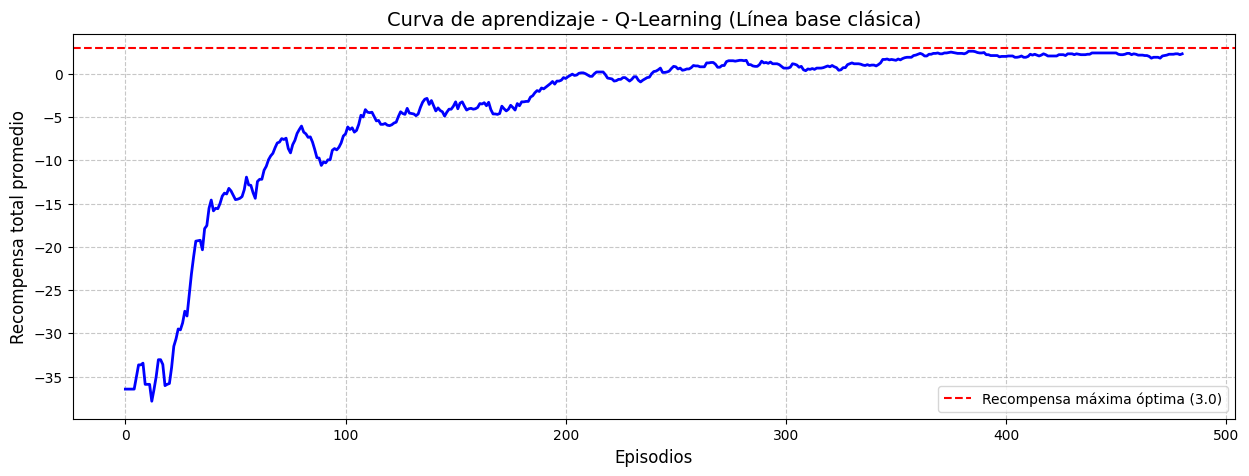

In [29]:
import matplotlib.pyplot as plt

# Se suaviza un poco la curva (Promedio móvil)
def media_movil(datos, ventana=20):
    return np.convolve(datos, np.ones(ventana)/ventana, mode='valid')

recompensas_suavizadas = media_movil(recompensas_por_episodio)

plt.figure(figsize=(15, 5))
plt.plot(recompensas_suavizadas, color='blue', linewidth=2)
plt.title('Curva de aprendizaje - Q-Learning (Línea base clásica)', fontsize=14)
plt.xlabel('Episodios', fontsize=12)
plt.ylabel('Recompensa total promedio', fontsize=12)
plt.axhline(y=3.0, color='r', linestyle='--', label='Recompensa máxima óptima (3.0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 5. Visualización del agente entrenado

In [31]:
import time
from IPython.display import clear_output # Esta librería borra la celda para crear el efecto de animación

def ver_juego_en_vivo(env, q_table):
    estado = env.reset()
    terminado = False
    pasos = 0
    
    while not terminado and pasos < 15:
        clear_output(wait=True) # Borra el texto anterior
        
        # Construir el mapa visual
        mapa = ""
        for i in range(env.size):
            for j in range(env.size):
                if [i, j] == env.agent_pos:
                    mapa += "🤖 "  # Agente
                elif [i, j] == env.goal_pos:
                    mapa += "🏁 "  # Meta
                else:
                    mapa += "⬜ "  # Casillas vacías
            mapa += "\n"
            
        print(mapa)
        print(f"Paso actual: {pasos}")
        
        time.sleep(0.6) # Velocidad a la que se mueve el agente
        
        # El agente consulta su tabla Q para elegir el movimiento perfecto
        accion = np.argmax(q_table[estado])
        estado, recompensa, terminado = env.step(accion)
        pasos += 1
        
    # Dibujar el cuadro final cuando gana
    clear_output(wait=True)
    mapa = ""
    for i in range(env.size):
        for j in range(env.size):
            if [i, j] == env.agent_pos:
                mapa += "😎 " # Al llegar a la meta
            else:
                mapa += "⬜ "
    print(mapa)
    print(f"¡Perfecto! Llegó a la meta en {pasos} pasos perfectos.")

# Se llama a la función para empezar
ver_juego_en_vivo(env, q_table)

⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ ⬜ 😎 
¡Perfecto! Llegó a la meta en 8 pasos perfectos.
